In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import pandas as pd
import os


In [2]:
# trim_ranges = {
#     "Camilo Command.m4a": [("RIGHT", 45000, 70000), ("UP", 100000, 115000), ("DOWN", 145000, 175000)],
#     "Nova Command.m4a": [("RIGHT", 40000, 60000), ("UP", 110000, 125000), ("DOWN", 175000, 180000)],
#     "Paula Command.m4a": [("RIGHT", 25000, 45000), ("UP", 87500, 100000), ("DOWN", 140000, 155000)],
#     "Selene Command.m4a": [("RIGHT", 30000, 60000), ("UP", 100000, 115000), ("DOWN", 140000, 160000)],
#     "Joel Command.aac": [("LEFT", 25000, 40000), ("RIGHT", 82500, 100000), ("UP", 140000, 150000), ("DOWN", 166000, 180000)],
  
#     "Left Camilo.m4a": [("LEFT", 10000, 35000)],
#     "Left Daniel.m4a": [("LEFT", 30000, 50000)],
#     "Left Jhon.m4a": [("LEFT", 30000, 50000)],
#     "Left Juan.m4a": [("LEFT", 35000, 50000)],
#     "Left Karen.m4a": [("LEFT", 10000, 30000)],
#     "Left Mariana.m4a": [("LEFT", 15000, 40000)],
#     "Left Nicolas.m4a": [("LEFT", 20000, 60000)],
#     "Left Nova.m4a": [("LEFT", 10000, 35000)],
#     "Left Paula.m4a": [("LEFT", 25000, 50000)],
#     "Left Selene.m4a": [("LEFT", 20000, 60000)],
    
#     "Up Jhon.m4a": [("UP",20000 ,30000)],
#     "Up Juan.m4a": [("UP",25000 ,45000 )],
#     "Up Karen.m4a": [("UP", 40000,60000 )],
#     "Up Mariana.m4a": [("UP", 30000,42000 )],
    
#     "Right Dani.m4a": [("RIGHT",20000 ,35000 )],
#     "Right Jhon.m4a": [("RIGHT",15000 ,35000 )],
#     "Right Juan.m4a": [("RIGHT",30000 ,50000 )],
#     "Right Karen.m4a": [("RIGHT",15000 ,35000 )],
#     "Right Mariana.m4a": [("RIGHT",25000 ,50000 )],
    
#     # "Down Dani.m4a": [("DOWN", , )],
#     "Down Jhon.m4a": [("DOWN",20000 ,50000 )],
#     "Down Juan.m4a": [("DOWN",25000 ,50000 )],
#     "Down Karen.m4a": [("DOWN",35000 ,60000 )],
#     "Down Mariana.m4a": [("DOWN", 15000, 50000)],
    
# }

start = 30000
end = 40000

trim_ranges = {
    "Left Mariana.m4a": [("LEFT", 19000, 39000)],
    "Left1 Mariana.m4a": [("LEFT", 22000, 31000)],
    "Left2 Mariana.m4a": [("LEFT", 24000, 32000)],
    "Left3 Mariana.m4a": [("LEFT", 23000, 32000)],
    "Left4 Mariana.m4a": [("LEFT", 30000, 40000)],
    "Left5 Mariana.m4a": [("LEFT", 25000, 35000)],
    "Left6 Mariana.m4a": [("LEFT", 26000, 35000)],
    "Left7 Mariana.m4a": [("LEFT", 33000, 42000)],
    "Left8 Mariana.m4a": [("LEFT", 15000, 35000)],
    "Left9 Mariana.m4a": [("LEFT", 25000, 40000)], 
    "Left10 Mariana.m4a": [("LEFT", 26000, 35000)],
   
    
    #Right
    
    "Right Mariana.m4a": [("RIGHT", 28000, 46000)],
    "Right1 Mariana.m4a": [("RIGHT", 22000, 24000)],
    "Right2 Mariana.m4a": [("RIGHT", 25000, 35000)],
    "Right3 Mariana.m4a": [("RIGHT", 20000, 35000)],
    "Right4 Mariana.m4a": [("RIGHT", 26000, 40000)],
    "Right5 Mariana.m4a": [("RIGHT", 18000, 30000)],
    "Right6 Mariana.m4a": [("RIGHT", 16000, 33000)],
    "Right7 Mariana.m4a": [("RIGHT", 26000, 40000)],
    "Right8 Mariana.m4a": [("RIGHT", 15000, 35000)],
    "Right9 Mariana.m4a": [("RIGHT", 16000, 30000)],
    "Right10 Mariana.m4a": [("RIGHT", 25000, 38000)],
    "Right11 Mariana.m4a": [("RIGHT", 24000, 35000)],
    
    #Up 
    
    "Up Mariana.m4a": [("UP", 35000, 45000)],
    "Up1 Mariana.m4a": [("UP", 20000, 30000)],
    "Up2 Mariana.m4a": [("UP", 23000, 33000)],
    "Up3 Mariana.m4a": [("UP", 20000, 28000)],
    "Up4 Mariana.m4a": [("UP", 18000, 25000)],
    "Up5 Mariana.m4a": [("UP", 15000, 22000)],
    "Up6 Mariana.m4a": [("UP", 28000, 37000)],
    "Up7 Mariana.m4a": [("UP", 18000, 28000)],
    "Up8 Mariana.m4a": [("UP", 25000, 33000)],
    "Up9 Mariana.m4a": [("UP", 18000, 28000)],
    "Up10 Mariana.m4a": [("UP", 17000, 26000)],
    "Up11 Mariana.m4a": [("UP", 23000, 32000)],
    
    #Down
    
    "Down Mariana.m4a": [("DOWN", 15000, 50000)],
    "Down1 Mariana.m4a": [("DOWN", 20000, 45000)],
    "Down2 Mariana.m4a": [("DOWN", 32000, 55000)],
    "Down3 Mariana.m4a": [("DOWN", 18000, 40000)],
    "Down4 Mariana.m4a": [("DOWN", 22000, 47000)],
    "Down5 Mariana.m4a": [("DOWN", 13000, 38000)],
    "Down6 Mariana.m4a": [("DOWN", 35000, 55000)],
    "Down7 Mariana.m4a": [("DOWN", 25000, 50000)],
    "Down8 Mariana.m4a": [("DOWN", 22000, 47000)],
    "Down9 Mariana.m4a": [("DOWN", 20000, 45000)],
    "Down10 Mariana.m4a": [("DOWN", 12000, 37000)],
    "Down11 Mariana.m4a": [("DOWN", 32000, 55000)],
}

# Recalculate all trim_ranges for 30000 sample length, centered on each original segment


fixed_window = 20000
new_trim_ranges = {}

for fname, segments in trim_ranges.items():
    new_segments = []
    for label, start, end in segments:
        center = (start + end) // 2
        half = fixed_window // 2
        new_start = max(center - half, 0)
        new_end = new_start + fixed_window
        new_segments.append((label, new_start, new_end))
    new_trim_ranges[fname] = new_segments

# Print new ranges for verification
for fname, segments in new_trim_ranges.items():
    print(f"{fname}:")
    for label, start, end in segments:
        print(f"  {label}: [{start}, {end}] (len={end-start})")

Left Mariana.m4a:
  LEFT: [19000, 39000] (len=20000)
Left1 Mariana.m4a:
  LEFT: [16500, 36500] (len=20000)
Left2 Mariana.m4a:
  LEFT: [18000, 38000] (len=20000)
Left3 Mariana.m4a:
  LEFT: [17500, 37500] (len=20000)
Left4 Mariana.m4a:
  LEFT: [25000, 45000] (len=20000)
Left5 Mariana.m4a:
  LEFT: [20000, 40000] (len=20000)
Left6 Mariana.m4a:
  LEFT: [20500, 40500] (len=20000)
Left7 Mariana.m4a:
  LEFT: [27500, 47500] (len=20000)
Left8 Mariana.m4a:
  LEFT: [15000, 35000] (len=20000)
Left9 Mariana.m4a:
  LEFT: [22500, 42500] (len=20000)
Left10 Mariana.m4a:
  LEFT: [20500, 40500] (len=20000)
Right Mariana.m4a:
  RIGHT: [27000, 47000] (len=20000)
Right1 Mariana.m4a:
  RIGHT: [13000, 33000] (len=20000)
Right2 Mariana.m4a:
  RIGHT: [20000, 40000] (len=20000)
Right3 Mariana.m4a:
  RIGHT: [17500, 37500] (len=20000)
Right4 Mariana.m4a:
  RIGHT: [23000, 43000] (len=20000)
Right5 Mariana.m4a:
  RIGHT: [14000, 34000] (len=20000)
Right6 Mariana.m4a:
  RIGHT: [14500, 34500] (len=20000)
Right7 Mariana.

In [3]:


# Directory containing .m4a files
audio_dir = "/run/media/joel/Programming1/Languages/Python/IABO/Audio"
# max_samples = 75000
loaded_signals = []

mfcc_dfs = {}

for filename in os.listdir(audio_dir):
    if filename.endswith(".m4a") or filename.endswith(".aac"):
        audio_path = os.path.join(audio_dir, filename)
        y, sr = librosa.load(audio_path, sr=None)
        # print(f"Loaded {filename} with sample rate {sr} and {len(y)} samples.")
        if filename in new_trim_ranges:
            for label, start, end in new_trim_ranges[filename]:
                trimmed_signal = y[start:end]
                user = filename.split()[0]
                loaded_signals.append((trimmed_signal, user , sr, label, filename))
               
                # print(f" - Trimmed {label} segment: {len(trimmed_signal)} samples")
# Store loaded signals and their sample rates in a vector

for filename in os.listdir(os.path.join(audio_dir,"left")):
    if filename.endswith(".m4a") or filename.endswith(".aac"):
        audio_path = os.path.join(os.path.join(audio_dir,"left"), filename)
        y, sr = librosa.load(audio_path, sr=None)
        if filename in new_trim_ranges:
            for label, start, end in new_trim_ranges[filename]:
                trimmed_signal = y[start:end]
                user = filename.split()[1].rsplit('.', 1)[0]
                loaded_signals.append((trimmed_signal, user , sr, label, filename))
        else:
            label = "LEFT"
            user = filename.split()[1].rsplit('.', 1)[0]
            loaded_signals.append((y, user , sr, label, filename))

for filename in os.listdir(os.path.join(audio_dir,"right")):
    if filename.endswith(".m4a") or filename.endswith(".aac"):
        audio_path = os.path.join(os.path.join(audio_dir,"right"), filename)
        y, sr = librosa.load(audio_path, sr=None)
        if filename in new_trim_ranges:
            for label, start, end in new_trim_ranges[filename]:
                trimmed_signal = y[start:end]
                user = filename.split()[1].rsplit('.', 1)[0]
                loaded_signals.append((trimmed_signal, user , sr, label, filename))
        else:
            label = "RIGHT"
            user = filename.split()[1].rsplit('.', 1)[0]
            loaded_signals.append((y, user , sr, label, filename))
#  up

for filename in os.listdir(os.path.join(audio_dir,"up")):
    if filename.endswith(".m4a") or filename.endswith(".aac"):
        audio_path = os.path.join(os.path.join(audio_dir,"up"), filename)
        y, sr = librosa.load(audio_path, sr=None)
        if filename in new_trim_ranges:
            for label, start, end in new_trim_ranges[filename]:
                trimmed_signal = y[start:end]
                user = filename.split()[1].rsplit('.', 1)[0]
                loaded_signals.append((trimmed_signal, user , sr, label, filename))
        else:
            label = "UP"
            user = filename.split()[1].rsplit('.', 1)[0]
            loaded_signals.append((y, user , sr, label, filename))
# down

for filename in os.listdir(os.path.join(audio_dir,"down")):
    if filename.endswith(".m4a") or filename.endswith(".aac"):
        audio_path = os.path.join(os.path.join(audio_dir,"down"), filename)
        y, sr = librosa.load(audio_path, sr=None)
        if filename in new_trim_ranges:
            for label, start, end in new_trim_ranges[filename]:
                trimmed_signal = y[start:end]
                user = filename.split()[1].rsplit('.', 1)[0]
                loaded_signals.append((trimmed_signal, user , sr, label, filename))
        else:
            label = "DOWN"
            user = filename.split()[1].rsplit('.', 1)[0]
            loaded_signals.append((y, user , sr, label, filename))


/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_118287/1213208857.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/usr/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_118287/1213208857.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/usr/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native

In [4]:
for i, (signal, user,sr, label, filename) in enumerate(loaded_signals):
    if user == "Mariana":
        print(f"Signal {i+1}: Filename={filename}, User={user}, Label={label}, Sample Rate={sr}, Signal Length={len(signal)} samples")


Signal 6: Filename=Left Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 samples
Signal 11: Filename=Left1 Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 samples
Signal 12: Filename=Left10 Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 samples
Signal 13: Filename=Left2 Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 samples
Signal 14: Filename=Left3 Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 samples
Signal 15: Filename=Left4 Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 samples
Signal 16: Filename=Left5 Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 samples
Signal 17: Filename=Left6 Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 samples
Signal 18: Filename=Left7 Mariana.m4a, User=Mariana, Label=LEFT, Sample Rate=48000, Signal Length=20000 s

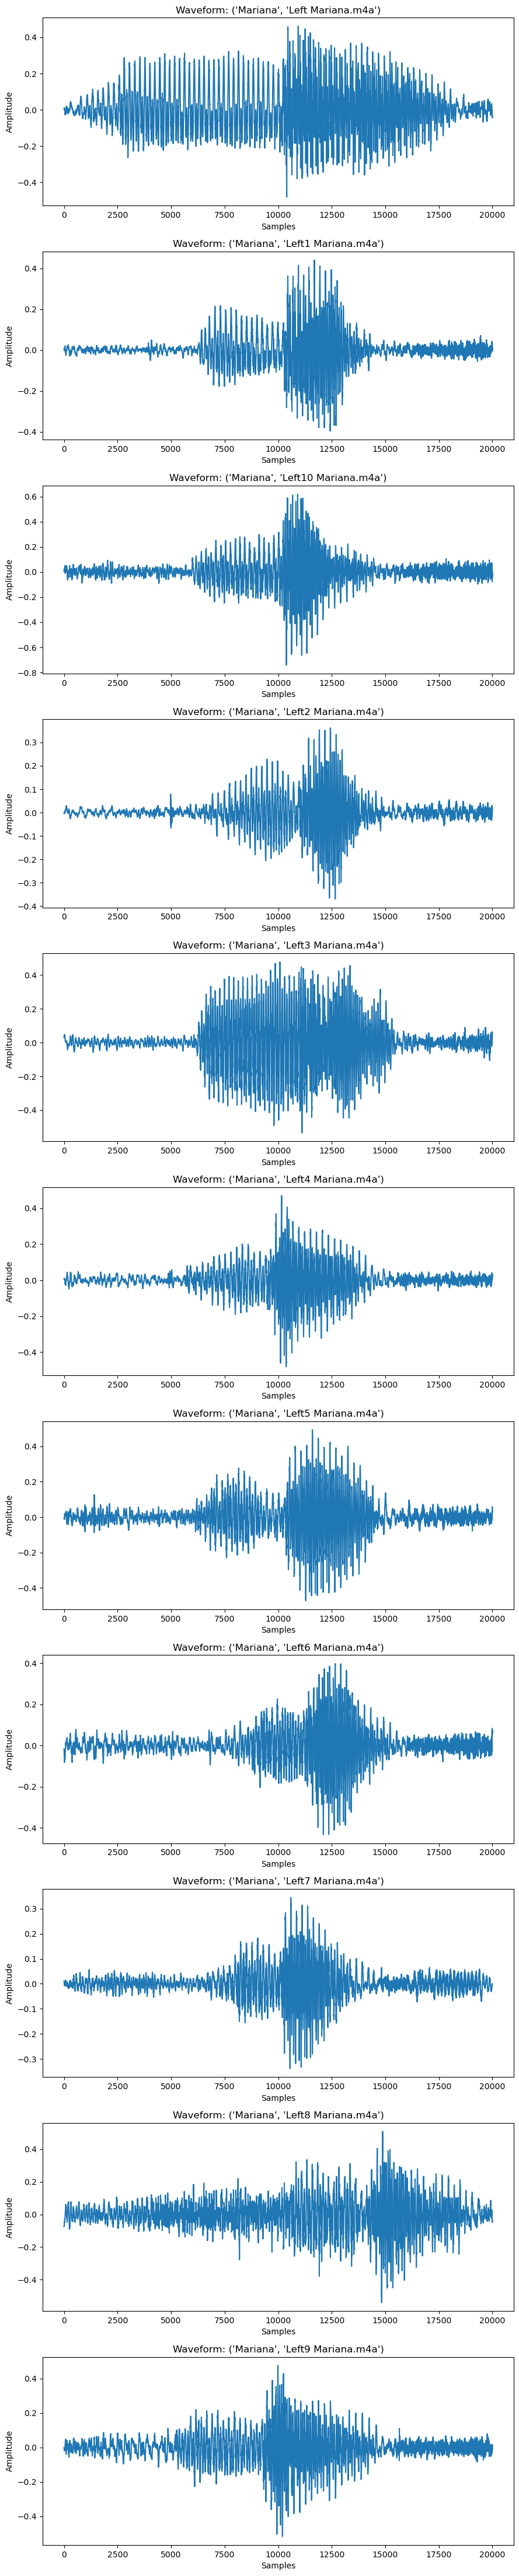

In [5]:
plt.figure(figsize=(9, 4 * len(loaded_signals)))
a = 1
for i, (signal, user,sr, label,filename) in enumerate(loaded_signals):
    if label == "LEFT" and user == "Mariana":
        
        plt.subplot(len(loaded_signals), 1, a + 1)
        plt.plot(signal)
        a += 1
        plt.title(f"Waveform: {user, filename}")
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [6]:
# Create an .xlsx file with average MFCCs per file (one row per file, not per window)

all_mfcc_dfs = []
for signal, user, sr, label, filename in loaded_signals:
    if user == "Mariana":
        # Compute MFCCs
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13, n_fft=12000, hop_length=7200)
        # Calculate mean MFCCs across all frames (axis=1 gives mean for each MFCC coefficient)
        mfcc_means = mfcc.mean(axis=1)
        # Create a DataFrame with a single row for the average MFCCs
        df = pd.DataFrame([mfcc_means], columns=[f"mfcc_{j+1}" for j in range(mfcc.shape[0])])
        # Add filename and label columns directly from loaded_signals
        df['filename'] = filename
        df['label'] = label
        df['user'] = user
        all_mfcc_dfs.append(df)

# Concatenate all DataFrames (one row per file)
mfcc_all = pd.concat(all_mfcc_dfs, ignore_index=True)

# Save to Excel
work_path = "/run/media/joel/Programming1/Languages/Python/IABO"
output_path = os.path.join(work_path, "mfcc_features_avg.xlsx")
mfcc_all.to_excel(output_path, index=False)
print(f"Average MFCC features saved to {output_path}")

Average MFCC features saved to /run/media/joel/Programming1/Languages/Python/IABO/mfcc_features_avg.xlsx
